In [1]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the UNSW training dataset
UNSW_train = pd.read_csv('UNSW_Train_File.csv')

# Read the UNSW test dataset
UNSW_test = pd.read_csv('UNSW_test_File.csv')

In [3]:
# Split the data into features (X) and target (y)
X_train = UNSW_train.drop('attack_cat', axis=1)
y_train = UNSW_train['attack_cat']
X_test = UNSW_test.drop('attack_cat', axis=1)
y_test = UNSW_test['attack_cat']

In [4]:
# Label Encode the target variable 'attack_cat'
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

In [5]:
# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(encoder.classes_), random_state=42)

# Train the model
xgb_model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=10, ...)

In [6]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Inverse transform the encoded values
y_pred_labels = encoder.inverse_transform(y_pred)

# Display the classification report
print(classification_report(y_test, y_pred_labels))

                precision    recall  f1-score   support

      Analysis       0.10      0.13      0.11       677
      Backdoor       0.03      0.04      0.04       583
           DoS       0.28      0.19      0.23      4089
      Exploits       0.61      0.83      0.70     11132
       Fuzzers       0.25      0.60      0.35      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.96      0.68      0.79     37000
Reconnaissance       0.93      0.81      0.87      3496
     Shellcode       0.48      0.54      0.51       378
         Worms       0.54      0.30      0.38        44

      accuracy                           0.73     82332
     macro avg       0.52      0.51      0.50     82332
  weighted avg       0.82      0.73      0.76     82332



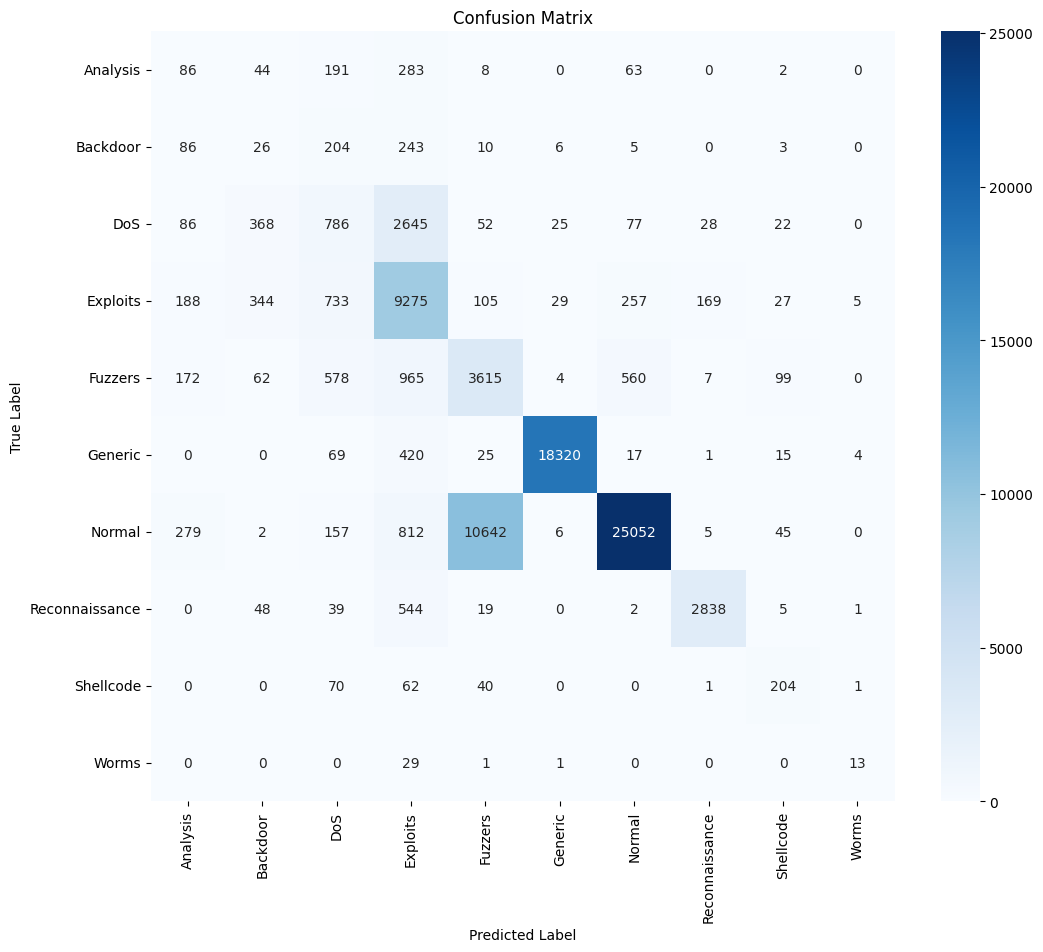

In [7]:
# Visualize the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred_labels, labels=encoder.classes_), annot=True, fmt='d',
            cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()